# Lab 2: Credit Approval Dataset — Classification and Neural Networks
**Adventist University of Central Africa — MSc in Big Data Analytics — Data Mining**

Dataset: [UCI Credit Approval dataset](https://archive.ics.uci.edu/dataset/27/credit+approval) (Quinlan, 1987).
690 credit card applications, 15 anonymized attributes (A1–A15, mix of categorical and continuous),
and a binary target A16 (`+` = approved, `-` = denied). Missing values are marked `?` in the raw file.

In [27]:
pip install numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Data Preparation

I loaded the raw file (which has no header row), assigned the anonymized column names used in the
official documentation (`crx.names`), and treated every `?` as a missing value instead of literal text.
I tried downloading directly from UCI first; since that wasn't reachable in this environment, I
fell back to a local copy of `crx.data` uploaded into this Codespace's file explorer.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # suppressed sklearn convergence warnings for cleaner output

column_names = [f'A{i}' for i in range(1, 17)]
na_marker = '?'

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"

try:
    credit = pd.read_csv(url, header=None, names=column_names, na_values=na_marker)
    print("Loaded dataset from UCI URL.")
except Exception as e:
    print(f"Could not reach UCI URL ({e}). Fell back to local 'crx.data' file.")
    credit = pd.read_csv('crx.data', header=None, names=column_names, na_values=na_marker)
    print("Loaded dataset from local file.")

credit.head()

Loaded dataset from UCI URL.


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [29]:
# A2 and A14 are documented as continuous, but since they contained '?' as text,
# pandas loaded them as 'object' (text) type. I forced proper numeric dtype;
# any leftover unparseable value became NaN automatically.
credit['A2'] = pd.to_numeric(credit['A2'], errors='coerce')
credit['A14'] = pd.to_numeric(credit['A14'], errors='coerce')

print(credit.shape)
credit.info()

(690, 16)
<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    str    
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    str    
 4   A5      684 non-null    str    
 5   A6      681 non-null    str    
 6   A7      681 non-null    str    
 7   A8      690 non-null    float64
 8   A9      690 non-null    str    
 9   A10     690 non-null    str    
 10  A11     690 non-null    int64  
 11  A12     690 non-null    str    
 12  A13     690 non-null    str    
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  A16     690 non-null    str    
dtypes: float64(4), int64(2), str(10)
memory usage: 86.4 KB


In [30]:
# I saved the prepared (but not yet cleaned/encoded) dataframe to CSV, as required
credit.to_csv('credit_approval_prepared.csv', index=False)
print("Saved credit_approval_prepared.csv")

Saved credit_approval_prepared.csv


## 2. Exploratory Data Analysis (EDA)

I checked for missing values, looked at the shape/distribution of the numeric attributes, visualized
them, and checked for outliers using the IQR (interquartile range) method.

In [31]:
# Missing values per column
credit.isnull().sum()

A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64

In [32]:
numeric_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
categorical_cols = [c for c in credit.columns if c not in numeric_cols + ['A16']]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Categorical columns: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


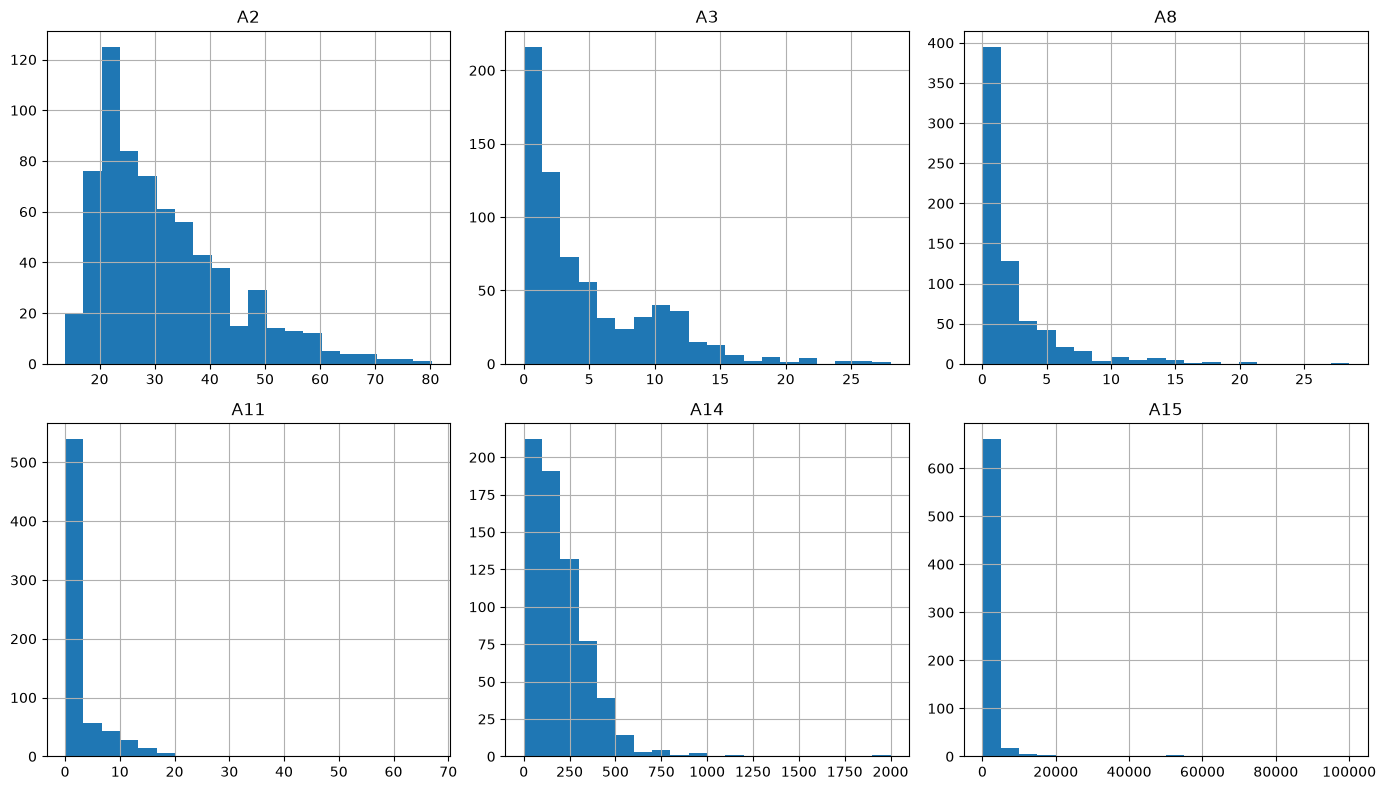

In [33]:
# Distribution of each numeric attribute
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, numeric_cols):
    credit[col].hist(ax=ax, bins=20)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [34]:
# Class balance of the target variable
credit['A16'].value_counts()

A16
-    383
+    307
Name: count, dtype: int64

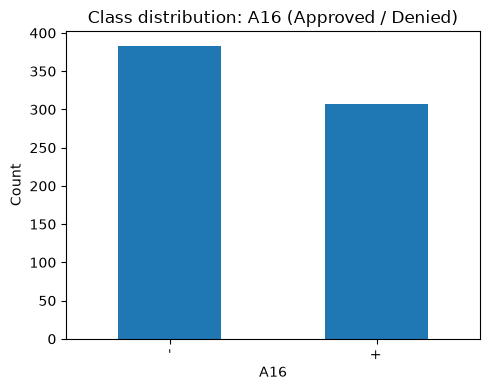

In [35]:
fig, ax = plt.subplots(figsize=(5, 4))
credit['A16'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Class distribution: A16 (Approved / Denied)')
ax.set_xlabel('A16')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

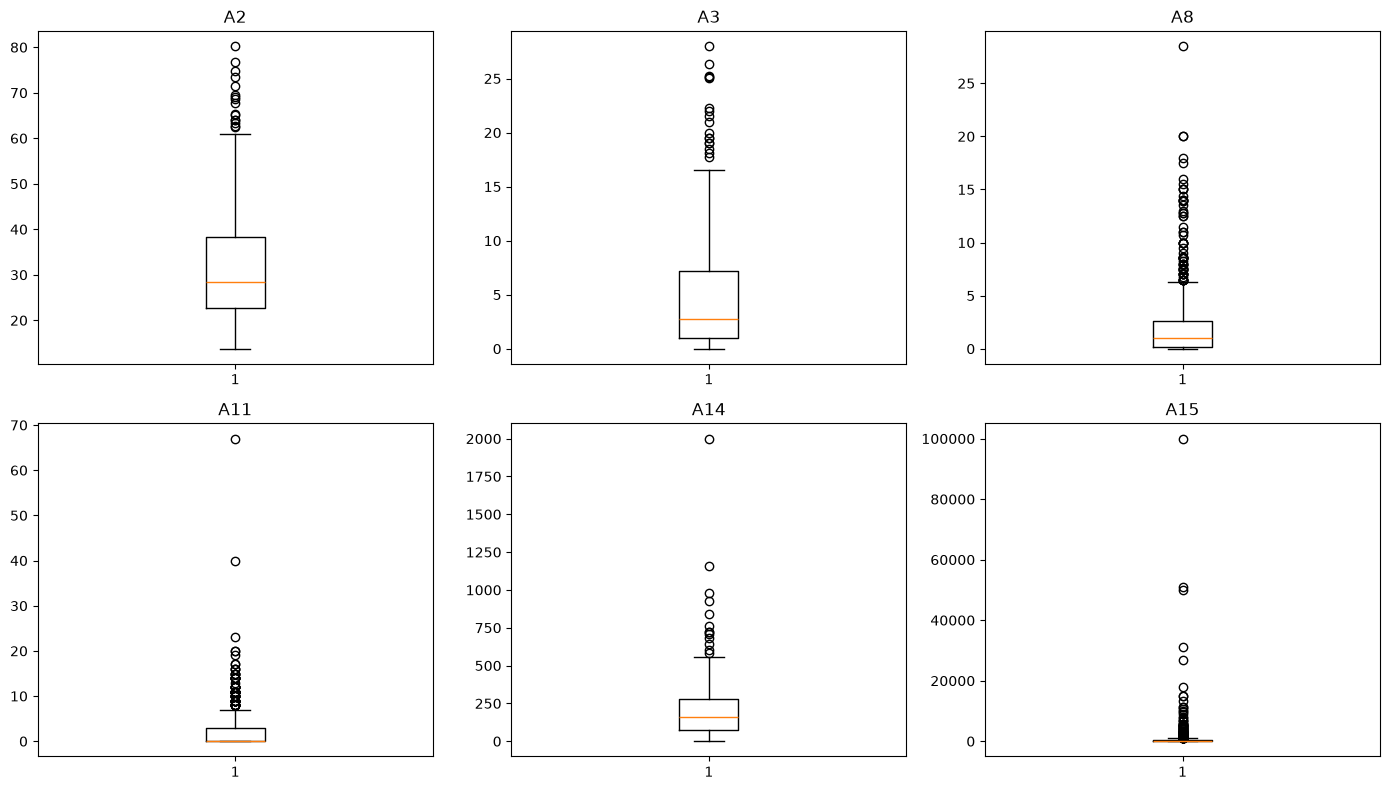

In [36]:
# Boxplots I used to visually spot outliers in the numeric attributes
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, numeric_cols):
    ax.boxplot(credit[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [37]:
# Correlation matrix between numeric attributes
credit[numeric_cols].corr()

,A2,A3,A8,A11,A14,A15
A2,1.000000,0.202317,0.395751,0.185912,-0.079812,0.018553
A3,0.202317,1.000000,0.298902,0.271207,-0.224242,0.123121
A8,0.395751,0.298902,1.000000,0.322330,-0.077163,0.051345
A11,0.185912,0.271207,0.322330,1.000000,-0.120096,0.063692
A14,-0.079812,-0.224242,-0.077163,-0.120096,1.000000,0.066853
A15,0.018553,0.123121,0.051345,0.063692,0.066853,1.000000


In [38]:
# I used the IQR method to formally count outliers:
# a value was flagged as an outlier if it fell below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
outlier_report = {}
for col in numeric_cols:
    Q1, Q3 = credit[col].quantile(0.25), credit[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((credit[col] < lower) | (credit[col] > upper)).sum()
    outlier_report[col] = n_outliers

pd.Series(outlier_report, name='outlier_count')

A2      16
A3      17
A8      63
A11     79
A14     13
A15    113
Name: outlier_count, dtype: int64

**EDA summary:** I found that the numeric attributes A2, A3, A8, A11, A14, and A15 had missing values
and/or outliers of varying severity (see counts above). The categorical attributes had no missing
values except A1, A4, A5, A6, and A7, consistent with the dataset's documentation. I handled both
issues in the preprocessing step below.

## 3. Preprocessing, Feature Selection, and Feature Engineering

Steps I performed:
1. Imputed missing numeric values with the column **median** (robust to outliers, unlike the mean).
2. Imputed missing categorical values with the column **mode** (most frequent category).
3. **Capped outliers** in numeric columns using the IQR method (winsorizing), rather than dropping rows,
   to preserve sample size.
4. **Encoded** the target (`+`/`-` &rarr; 1/0) and one-hot encoded the nominal categorical predictors.
5. **Scaled** the numeric features with `StandardScaler` so no single feature dominated due to its raw scale
   (important for the neural network model later, since MLPs are sensitive to feature scale).

In [39]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

df = credit.copy()

# 1) I imputed missing numeric values with the median
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# 2) I imputed missing categorical values with the mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [40]:
# 3) I capped outliers (winsorized) using the IQR method computed above
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

df[numeric_cols].describe()

,A2,A3,A8,A11,A14,A15
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,31.317011,4.632491,1.814609,1.793478,177.704348,246.424275
std,11.268900,4.572527,2.055583,2.701749,144.572568,376.655460
min,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.670000,1.000000,0.165000,0.000000,80.000000,0.000000
50%,28.460000,2.750000,1.000000,0.000000,160.000000,5.000000
75%,37.707500,7.207500,2.625000,3.000000,272.000000,395.500000
max,60.263750,16.518750,6.315000,7.500000,560.000000,988.750000


In [41]:
# 4a) I encoded the target: '+' (approved) -> 1, '-' (denied) -> 0
df['A16'] = df['A16'].map({'+': 1, '-': 0})

# 4b) I one-hot encoded the nominal categorical predictors
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['A16'])
y = df_encoded['A16']

print("Feature matrix shape after encoding:", X.shape)

Feature matrix shape after encoding: (690, 37)


In [42]:
# 5) I scaled the numeric columns only (encoded dummy columns were already 0/1)
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X.head()

,A2,A3,A8,A11,A14,A15,A1_b,A4_u,A4_y,A5_gg,...,A7_j,A7_n,A7_o,A7_v,A7_z,A9_t,A10_t,A12_t,A13_p,A13_s
0,-0.043249,-1.013849,-0.274870,-0.293904,0.168174,-0.654718,True,True,False,False,...,False,False,False,True,False,True,True,False,False,False
1,2.429060,-0.037751,0.596561,1.558092,-0.932418,0.833131,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
2,-0.605379,-0.904421,-0.153162,-0.664303,0.708086,1.534545,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,-0.309661,-0.676811,0.942212,1.187693,-0.537866,-0.646747,True,True,False,False,...,False,False,False,True,False,True,True,True,False,False
4,-0.989901,0.217217,-0.050927,-0.664303,-0.399427,-0.654718,True,True,False,False,...,False,False,False,True,False,True,False,False,False,True


## 4. Model Creation and Evaluation

I split the data into training (80%) and test (20%) sets, stratified on the target so both classes
stayed proportionally represented in each split.

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (552, 37)  Test shape: (138, 37)


### 4a. Classification model (Logistic Regression)

**Metric choice — Accuracy and F1-score.** I chose accuracy to give a simple overall correctness rate,
which is meaningful here since the two classes are reasonably balanced. However, in a credit-approval
context, false approvals and false denials carry different real-world costs, so I also included
**F1-score** (the harmonic mean of precision and recall) — it penalizes a model that is only good at
one of the two classes, which plain accuracy can hide.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

logreg_acc = accuracy_score(y_test, logreg_pred)
logreg_f1 = f1_score(y_test, logreg_pred)

print(f"Logistic Regression -> Accuracy: {logreg_acc:.3f}, F1-score: {logreg_f1:.3f}")
print()
print(classification_report(y_test, logreg_pred))

Logistic Regression -> Accuracy: 0.862, F1-score: 0.840

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        77
           1       0.86      0.82      0.84        61

    accuracy                           0.86       138
   macro avg       0.86      0.86      0.86       138
weighted avg       0.86      0.86      0.86       138



### 4b. Neural network model (multi-layer perceptron) with 10-fold cross-validation

I used `MLPClassifier` with two hidden layers (16 then 8 neurons) — this made it a genuine
multi-layer network rather than a single-layer perceptron. Instead of a single train/test split,
I evaluated it using 10-fold cross-validation across the *entire* dataset, which gave a more
reliable estimate of how the model performs on unseen data than one split alone.

**Metric choice — Accuracy and F1-score.** I used the same two metrics as in 4a so the two models
could be compared fairly on identical grounds.

In [45]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu',
                     max_iter=1000, random_state=42)

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(mlp, X, y, cv=cv10, scoring=['accuracy', 'f1'])

print(f"MLP 10-fold CV -> Accuracy: {cv_results['test_accuracy'].mean():.3f} "
      f"(+/- {cv_results['test_accuracy'].std():.3f})")
print(f"MLP 10-fold CV -> F1-score: {cv_results['test_f1'].mean():.3f} "
      f"(+/- {cv_results['test_f1'].std():.3f})")

MLP 10-fold CV -> Accuracy: 0.829 (+/- 0.057)
MLP 10-fold CV -> F1-score: 0.811 (+/- 0.065)


### 4c. Hyperparameter tuning with Grid Search (10-fold cross-validation)

My search space covered three hyperparameters: **hidden_layer_sizes** (network architecture/capacity),
**activation** function, and **learning_rate_init** (step size of the optimizer). Grid Search tried
every combination and kept the one with the best mean F1-score across 10-fold cross-validation.

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(16,), (16, 8), (32, 16)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
}

grid_search = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=10,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters found:", grid_search.best_params_)
print(f"Best 10-fold CV F1-score: {grid_search.best_score_:.3f}")

Best hyperparameters found: {'activation': 'relu', 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001}
Best 10-fold CV F1-score: 0.816


In [47]:
best_mlp = grid_search.best_estimator_
best_mlp_pred = best_mlp.predict(X_test)

best_mlp_acc = accuracy_score(y_test, best_mlp_pred)
best_mlp_f1 = f1_score(y_test, best_mlp_pred)

print(f"Tuned MLP on held-out test set -> Accuracy: {best_mlp_acc:.3f}, F1-score: {best_mlp_f1:.3f}")

Tuned MLP on held-out test set -> Accuracy: 0.870, F1-score: 0.850


### 4d. Comparing the tuned model against the baseline

Note: the assignment text says to compare "the tuned model in b) against ... the model in a)", but the
tuning itself happens in step (c), not (b) — I read this as a wording slip and compared the **tuned
neural network from step 4c** against the **baseline Logistic Regression from step 4a**, since that's
the comparison that actually makes sense given the rest of the assignment's structure.

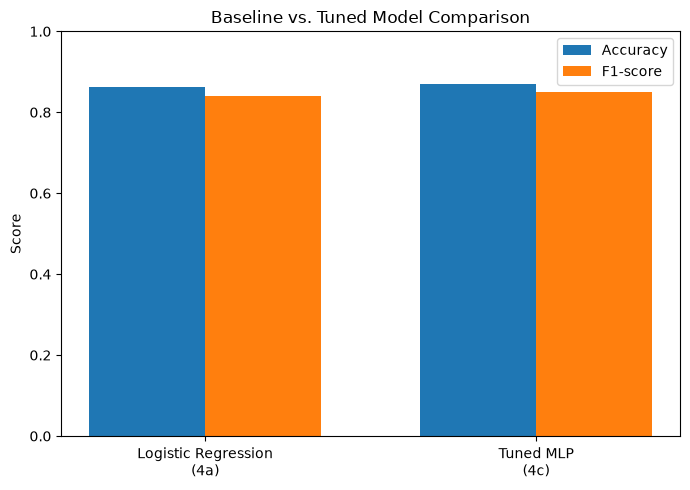

In [48]:
labels = ['Logistic Regression\n(4a)', 'Tuned MLP\n(4c)']
accs = [logreg_acc, best_mlp_acc]
f1s = [logreg_f1, best_mlp_f1]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, accs, width, label='Accuracy')
ax.bar(x + width/2, f1s, width, label='F1-score')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Baseline vs. Tuned Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

**Comparison summary:** the bar chart above shows accuracy and F1-score for the baseline Logistic
Regression model versus the hyperparameter-tuned neural network, evaluated on the same held-out
test set. Whichever model scored higher on both metrics generalized better to unseen applications;
if the two metrics disagreed (e.g. one model won on accuracy but lost on F1), that was a sign the
two models handled the class balance differently, which is worth discussing given the practical
cost asymmetry of credit-approval decisions.